# DCDM ↔ accDM: pełna mapa z uzupełnionym rogiem low-ε

**Cel:** zobaczyć, jak mogłaby wyglądać brakująca część mapy accDM, gdyby dziedziczyła
kształt DCDM po przesunięciu w $\log_{10}\Gamma$. Główny rysunek ma **pełen zakres
osi jak przesłany przykład**; zbliżenie rogu jest dodatkowym rysunkiem.

**Uruchomienie:** umieść notebook w projekcie `lyalpha_one_loop` (lub podkatalogu),
sprawdź ścieżki w następnej komórce i wybierz **Run All**. Wymagane: NumPy, pandas,
SciPy i Matplotlib. Nie uruchamia CLASS ani nowych fitów; czyta istniejące CSV/JSON.
Nie wymaga wykonania notebooka 07 i nie korzysta z jego starego, zamrożonego snapshotu.

Produkty: pełna mapa DCDM/accDM, zbliżenie z wariantem czysto hipotetycznym,
wrażliwość na przesunięcie ±0.20 dex, CSV z pochodzeniem każdej wartości i metadane.
PNG/PDF zapisują się do **nowego** katalogu `analysis_dcdm_accdm_corner_comparison_v1`.

Domyślnie nowe założenie zmienia **tylko brakujące punkty** przy
$\log_{10}m_{\rm acc}>18$ i $\log_{10}f_{\rm acc}>-1$.
Wszystkie ukończone fity zostają zachowane, z dwoma jawnymi wyjątkami odziedziczonymi
z dostarczonych notebooków: lokalna naprawa punktów $(14.714286,-1.375)$ i
$(15,-1.375)$. Ich surowe wartości pozostają w eksporcie; naprawę można wyłączyć.

**To scenariusz warunkowy, nie nowy wynik likelihood.** Kontury w uzupełnionym rogu
są przerywane. Liczby 2.30 i 5.991 pozostają poziomami pomocniczymi; prognozowane
kontury nie są zmierzonymi ograniczeniami ufności. Minima obu modeli są
normalizowane osobno: DCDM do zmierzonego minimum, accDM do stabilnego zmierzonego
punktu odniesienia z dotychczasowej analizy. Sam kolor nie porównuje absolutnej
jakości dopasowania obu modeli.

W załączonej najnowszej analizie granica wynosiła $\log_{10}\epsilon_{\rm eff}
\simeq-3.34968$, a widoczne przesunięcie DCDM $-0.919606$ dex. Tutaj przesunięcie
jest ponownie szacowane wyłącznie ze zmierzonych punktów starej domeny;
tamta wartość stanowi jawny fallback, jeśli kalibracja ma za mało przekrojów.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from scipy.interpolate import LinearNDInterpolator, RegularGridInterpolator, griddata

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string() if hasattr(value, "to_string") else value)


def find_project_root():
    override = os.environ.get("ACCDM_PROJECT_ROOT")
    if override:
        return Path(override).expanduser().resolve()
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if ((candidate / "lyalpha_pt").is_dir()
                or (candidate / "runs/accdm").is_dir()):
            return candidate
    return start


def env_path(name, default):
    return Path(os.environ.get(name, str(default))).expanduser().resolve()


PROJECT_ROOT = find_project_root()  # można zastąpić przez Path('/.../lyalpha_one_loop')
BASE_ANALYSIS_DIR = env_path(
    "ACCDM_BASE_ANALYSIS_DIR",
    PROJECT_ROOT / "runs/accdm/analysis_updated_hybrid_q1001_q5001_recovery_v1",
)
OUTPUT_DIR = env_path(
    "ACCDM_COMPARISON_OUTPUT_DIR",
    PROJECT_ROOT / "runs/accdm/analysis_dcdm_accdm_corner_comparison_v1",
)
# None = automatyczne wyszukanie tego samego CSV co w notebooku 07.
DCDM_PROFILE_OVERRIDE = os.environ.get("ACCDM_DCDM_PROFILE_CSV")
EXTENSION_CAMPAIGNS = [
    dict(label="loweps_low_q1001", region="low", momentum_bins=1001, priority=100,
         directory=env_path("ACCDM_LOWEPS_LOWF_CAMPAIGN",
             PROJECT_ROOT / "runs/accdm/accdm_scan_loweps_lowf_q1001_v1")),
    dict(label="loweps_high_q5001", region="high", momentum_bins=5001, priority=100,
         directory=env_path("ACCDM_LOWEPS_HIGHF_CAMPAIGN",
             PROJECT_ROOT / "runs/accdm/accdm_scan_loweps_highf_q5001_v1")),
]

# Najważniejsze pokrętła scenariusza.
SHIFT_QUERY_DEX = None        # None: kalibracja; +0.92 przesuwa widoczny DCDM W LEWO.
SHIFT_FALLBACK_DEX = 0.9196060713694787  # wynik zapisany w załączonym notebooku
SHIFT_BOUNDS = (-1.5, 1.5)
TEMPLATE_AMPLITUDE = 1.0      # 1 = zachowany kontrast Δχ²; to założenie, nie dopasowanie
TEMPLATE_OFFSET = 0.0         # opcjonalna zmiana poziomu daleko od brzegu
EPS_BLEND_DEX = 0.18          # szerokość zszycia ze starą domeną w log10 ε
GAMMA_BLEND_DEX = 0.18        # zszycie z ukończonym pasem f <= 0.1
SHIFT_SENSITIVITY_DEX = 0.20  # warianty, NIE przedział wiarygodności

# Po przesunięciu skrajnie duże Γ mogą wyjść poza siatkę DCDM.
# 'hold' = jawna stała kontynuacja wartości na brzegu Γ (oznaczona w audycie).
# 'mask' = pozostaw tam brak koloru; brak ekstrapolacji ε w obu trybach.
TEMPLATE_GAMMA_OUTSIDE = "hold"

ORIGINAL_MAX_LOGM = 18.0
TRANSITION_LOGF = -1.0
T_REFERENCE_GYR = 14.0
STABLE_LOGEPS_WINDOW = (-2.5, -2.0)
TRUST_REQUIRE_OPTIMIZER_SUCCESS = True
MIN_TRUSTED_BOUND_DISTANCE = 0.02
REPAIR_KNOWN_OUTLIERS = True
KNOWN_LOWF_REPAIR_COORDS = (
    ((14.7142857142857, -1.375), (15.0, -1.375))
    if REPAIR_KNOWN_OUTLIERS else ()
)

PLOT_XLIM = (-5.15, 0.0)
PLOT_YLIM = (-4.0, -0.31)
DISPLAY_DELTA_MAX = 20.0
CONTOUR_LEVELS = (2.30, 5.991)
PLOT_RESOLUTION = (650, 520)
SHOW_EXTENSION_POINTS = True
SHOW_FORECAST_HATCH = False   # kontury prognozy zawsze przerywane
SAVE_OUTPUTS = os.environ.get("ACCDM_SAVE_OUTPUTS", "1") != "0"

plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 12,
    "figure.dpi": 110, "savefig.dpi": 250,
    "axes.spines.top": True, "axes.spines.right": True,
})
assert EPS_BLEND_DEX > 0 and GAMMA_BLEND_DEX > 0
assert TEMPLATE_AMPLITUDE > 0
assert TEMPLATE_GAMMA_OUTSIDE in {"hold", "mask"}
print("Project:", PROJECT_ROOT)
print("Output :", OUTPUT_DIR)

Project: /home/2/ks405818/Master/lyalpha_one_loop
Output : /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_dcdm_accdm_corner_comparison_v1


## 1. Bieżące fity accDM

Wczytywanie zachowuje kryteria z załączników: rozszerzenie jest ukończone tylko
wtedy, gdy istnieje poprawny `fits/<point>.json` oraz `status/fit/<point>.done.json`
i nie ma markera niepowodzenia. Priorytet ma ukończony nowszy fit w tym samym punkcie.
Brak manifestu jest błędem konfiguracji, a nie dowodem, że kampania jest pusta.

In [2]:
def active_mask(frame):
    if "active" not in frame:
        return np.ones(len(frame), dtype=bool)
    return frame["active"].astype(str).str.strip().str.lower().isin({"true", "1", "yes"})


def coordinate_key(logm, logf):
    return f"{float(logm):.10f}|{float(logf):.10f}"


def fit_summary(path):
    payload = json.loads(path.read_text(encoding="utf-8"))
    loop = payload.get("fits", {}).get("one_loop")
    if loop is None or not np.isfinite(float(loop.get("chi2", np.nan))):
        return None
    diagnostics = loop.get("boundary_diagnostics", [])
    nearest = None
    if diagnostics:
        nearest = min(
            diagnostics,
            key=lambda item: float(item["relative_distance_to_nearest_bound"]),
        )
    return {
        "chi2_one_loop": float(loop["chi2"]),
        "chi2_per_dof": float(loop.get("chi2_per_dof", np.nan)),
        "optimizer_success": bool(loop.get("optimizer_success", False)),
        "minimum_bound_distance": (
            float(nearest["relative_distance_to_nearest_bound"])
            if nearest is not None else np.nan
        ),
        "minimum_bound_parameter": nearest["parameter"] if nearest is not None else None,
    }


def load_extension_campaign(source):
    directory = Path(source["directory"])
    manifest_path = directory / "manifest.csv"
    if not manifest_path.is_file():
        raise FileNotFoundError(f"Missing extension manifest: {manifest_path}")
    manifest = pd.read_csv(manifest_path)
    manifest = manifest.loc[active_mask(manifest)].copy()
    rows = []
    for record in manifest.to_dict(orient="records"):
        point_id = str(record["point_id"])
        fit_path = directory / "fits" / f"{point_id}.json"
        fit_done = directory / "status/fit" / f"{point_id}.done.json"
        fit_failed = directory / "status/fit" / f"{point_id}.failed.json"
        theory_path = directory / "theory" / f"{point_id}.npz"
        theory_done = directory / "status/theory" / f"{point_id}.done.json"
        theory_failed = directory / "status/theory" / f"{point_id}.failed.json"
        fit_has_failure_marker = fit_failed.is_file()
        theory_has_failure_marker = theory_failed.is_file()
        row = {
            **record,
            "coordinate_key": coordinate_key(record["log10m_acc"], record["log10f_acc"]),
            "expected_region": source["region"],
            "source_label": source["label"],
            "source_directory": str(directory),
            "source_priority": int(source["priority"]),
            "momentum_bins": int(source["momentum_bins"]),
            "theory_complete": (
                theory_path.is_file() and theory_done.is_file()
                and not theory_has_failure_marker
            ),
            "theory_failed": theory_has_failure_marker,
            "fit_complete": (
                fit_path.is_file() and fit_done.is_file()
                and not fit_has_failure_marker
            ),
            "fit_failed": fit_has_failure_marker,
            "chi2_one_loop": np.nan,
        }
        if row["fit_complete"]:
            parsed = fit_summary(fit_path)
            if parsed is not None:
                row.update(parsed)
        row["missing_reason"] = (
            "fit failed" if row["fit_failed"] else
            "theory failed" if row["theory_failed"] else
            "fit pending or missing" if row["theory_complete"] else
            "theory active, pending, or absent"
        )
        rows.append(row)
    return pd.DataFrame(rows)


base_sampled_path = BASE_ANALYSIS_DIR / "updated_hybrid_sampled_profile_likelihood.csv"
base_missing_path = BASE_ANALYSIS_DIR / "updated_hybrid_cross_markers.csv"
summary_path = BASE_ANALYSIS_DIR / "updated_hybrid_analysis_summary.json"
if not base_sampled_path.is_file():
    raise FileNotFoundError(base_sampled_path)

base_sampled = pd.read_csv(base_sampled_path)
base_missing = (
    pd.read_csv(base_missing_path)
    if base_missing_path.is_file()
    else pd.DataFrame(columns=["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"])
)
required = {"log10m_acc", "log10f_acc", "chi2_one_loop"}
missing_columns = required - set(base_sampled.columns)
if missing_columns:
    raise KeyError(f"Base accDM table lacks columns: {sorted(missing_columns)}")

analysis_summary = (
    json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.is_file() else {}
)
LCDM_ONE_LOOP_CHI2 = float(analysis_summary.get("lcdm_reference_chi2", 193.105787))

base_sampled = base_sampled.loc[np.isfinite(base_sampled["chi2_one_loop"])].copy()
if "fit_complete" in base_sampled:
    complete = base_sampled["fit_complete"].astype(str).str.lower().isin({"true", "1", "yes"})
    base_sampled = base_sampled.loc[complete].copy()
if "fit_failed" in base_sampled:
    failed = base_sampled["fit_failed"].astype(str).str.lower().isin({"true", "1", "yes"})
    base_sampled = base_sampled.loc[~failed].copy()
base_sampled[["log10m_acc", "log10f_acc"]] = base_sampled[["log10m_acc", "log10f_acc"]].round(10)
base_sampled["coordinate_key"] = [
    coordinate_key(m, f) for m, f in zip(base_sampled["log10m_acc"], base_sampled["log10f_acc"])
]
base_sampled["expected_region"] = np.where(
    base_sampled["log10f_acc"] <= TRANSITION_LOGF, "low", "high"
)
base_sampled["source_priority"] = 0
if "source_label" not in base_sampled:
    base_sampled["source_label"] = "validated_hybrid_base"
if "momentum_bins" not in base_sampled:
    base_sampled["momentum_bins"] = np.where(
        base_sampled["log10f_acc"] <= TRANSITION_LOGF, 1001, 5001
    )

base_missing[["log10m_acc", "log10f_acc"]] = base_missing[["log10m_acc", "log10f_acc"]].astype(float).round(10)
if True:  # również pusta tabela ma potrzebne kolumny
    base_missing["coordinate_key"] = [
        coordinate_key(m, f) for m, f in zip(base_missing["log10m_acc"], base_missing["log10f_acc"])
    ]
    base_missing["expected_region"] = np.where(
        base_missing["log10f_acc"] <= TRANSITION_LOGF, "low", "high"
    )

extension_frames = [load_extension_campaign(source) for source in EXTENSION_CAMPAIGNS]
extension_inventory = pd.concat(extension_frames, ignore_index=True, sort=False)
extension_inventory[["log10m_acc", "log10f_acc"]] = extension_inventory[["log10m_acc", "log10f_acc"]].round(10)
extension_completed = extension_inventory.loc[np.isfinite(extension_inventory["chi2_one_loop"])].copy()

sampled = pd.concat([base_sampled, extension_completed], ignore_index=True, sort=False)
sampled = (
    sampled.sort_values(["coordinate_key", "source_priority", "source_label"])
    .drop_duplicates("coordinate_key", keep="last")
    .copy()
)

if "optimizer_success" in sampled:
    optimizer_success = sampled["optimizer_success"]
    if optimizer_success.dtype != bool:
        optimizer_success = optimizer_success.astype(str).str.strip().str.lower().isin(
            {"true", "1", "yes"}
        )
    else:
        optimizer_success = optimizer_success.fillna(False)
else:
    optimizer_success = pd.Series(True, index=sampled.index)

bound_distance = pd.to_numeric(
    sampled.get("minimum_bound_distance", pd.Series(np.nan, index=sampled.index)),
    errors="coerce",
)
trusted_for_forecast = pd.Series(True, index=sampled.index)
if TRUST_REQUIRE_OPTIMIZER_SUCCESS:
    trusted_for_forecast &= optimizer_success
# Brak diagnostyki granic nie jest automatycznie porażką. Jeżeli diagnostyka jest
# dostępna, odrzucamy tylko rozwiązania rzeczywiście przyklejone do ściany boxa.
trusted_for_forecast &= bound_distance.isna() | (
    bound_distance >= MIN_TRUSTED_BOUND_DISTANCE
)
configured_repair_keys = {
    coordinate_key(logm, logf) for logm, logf in KNOWN_LOWF_REPAIR_COORDS
}
trusted_for_forecast &= ~sampled["coordinate_key"].isin(configured_repair_keys)
sampled["trusted_for_forecast"] = trusted_for_forecast.astype(bool)

base_expected = pd.concat([
    base_sampled[["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"]],
    base_missing[["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"]],
], ignore_index=True)
extension_expected = extension_inventory[
    ["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"]
]
expected_points = (
    pd.concat([base_expected, extension_expected], ignore_index=True)
    .drop_duplicates("coordinate_key", keep="last")
    .sort_values(["log10f_acc", "log10m_acc"])
    .reset_index(drop=True)
)
missing_now = expected_points.loc[
    ~expected_points["coordinate_key"].isin(sampled["coordinate_key"])
].copy()

extension_status = extension_inventory.groupby("source_label").agg(
    planned=("point_id", "size"),
    theory_complete=("theory_complete", "sum"),
    theory_failed=("theory_failed", "sum"),
    fit_complete=("fit_complete", "sum"),
    fit_failed=("fit_failed", "sum"),
    fitted=("chi2_one_loop", "count"),
)
extension_status["coverage"] = extension_status["fitted"] / extension_status["planned"]

print("Validated base points   :", len(base_sampled))
print("Completed extension fits:", len(extension_completed))
print("Expected full grid cells:", len(expected_points))
print("Missing now             :", len(missing_now))
print("Trusted forecast anchors:", int(sampled["trusted_for_forecast"].sum()),
      "/", len(sampled))
display(extension_status)

Validated base points   : 1425
Completed extension fits: 175
Expected full grid cells: 1740
Missing now             : 140
Trusted forecast anchors: 1578 / 1600


,planned,theory_complete,theory_failed,fit_complete,fit_failed,fitted,coverage
source_label,,,,,,,
loweps_high_q5001,120,8,1,8,0,8,0.066667
loweps_low_q1001,170,167,3,167,0,167,0.982353


## 2. Osi i punkt odniesienia

Zachowane są dokładnie efektywne przeliczenia z Twoich notebooków:
$\eta=10^{11-\log_{10}(m/\mathrm{GeV})}$,
$r=\sqrt{\eta(\eta+2)}$, $\epsilon_{\rm eff}=r/(\sqrt{1+r^2}+r)$,
$\Gamma_{\rm eff}=-\ln(1-f_{\rm acc})/(14\,\mathrm{Gyr})$.
To przyjęte współrzędne porównawcze, a nie dowód równoważności modeli.
$f=1$ odpowiada $\Gamma_{\rm eff}=\infty$; nie umieszczamy tego punktu pod skończoną
wartością Γ. Kolor przy skończonych Γ pochodzi z interpolacji w natywnej frakcji.

Prognoza nigdy nie wyznacza na nowo minimum accDM.

In [3]:
def eta_from_log10_mass(log10m_acc):
    return 10.0 ** (11.0 - np.asarray(log10m_acc, dtype=float))


def epsilon_effective_from_log10_mass(log10m_acc):
    eta = eta_from_log10_mass(log10m_acc)
    recoil = np.sqrt(eta * (eta + 2.0))
    return recoil / (np.sqrt(1.0 + recoil**2) + recoil)


def gamma_effective_from_log10_fraction(log10f_acc, t_reference_gyr=T_REFERENCE_GYR):
    fraction = 10.0 ** np.asarray(log10f_acc, dtype=float)
    gamma = np.full_like(fraction, np.inf, dtype=float)
    finite = fraction < 1.0
    gamma[finite] = -np.log1p(-fraction[finite]) / float(t_reference_gyr)
    return gamma


sampled["log10_epsilon_eff"] = np.log10(
    epsilon_effective_from_log10_mass(sampled["log10m_acc"])
)
sampled["log10_gamma_eff"] = np.log10(
    gamma_effective_from_log10_fraction(sampled["log10f_acc"])
)

repair_keys = {coordinate_key(m, f) for m, f in KNOWN_LOWF_REPAIR_COORDS}
stable_candidates = sampled.loc[
    sampled["log10_epsilon_eff"].between(*STABLE_LOGEPS_WINDOW)
    & (sampled["log10f_acc"] <= TRANSITION_LOGF + 1e-12)
    & ~sampled["coordinate_key"].isin(repair_keys)
].copy()
if stable_candidates.empty:
    raise RuntimeError("No measured low-f point lies in the stable epsilon window.")

stable_reference = stable_candidates.loc[stable_candidates["chi2_one_loop"].idxmin()]
REFERENCE_CHI2 = float(stable_reference["chi2_one_loop"])

print("Stable measured reference")
print(" point  :", stable_reference.get("point_id", stable_reference["coordinate_key"]))
print(f" logm   : {stable_reference['log10m_acc']:.6f}")
print(f" logf   : {stable_reference['log10f_acc']:.6f}")
print(f" logeps : {stable_reference['log10_epsilon_eff']:.6f}")
print(f" chi2   : {REFERENCE_CHI2:.9f}")
print(f" vs LCDM: {REFERENCE_CHI2 - LCDM_ONE_LOOP_CHI2:+.9f}")

Stable measured reference
 point  : accdm_logm15p7142857142857_logfm1p3
 logm   : 15.714286
 logf   : -1.300000
 logeps : -2.209324
 chi2   : 188.986412635
 vs LCDM: -4.210197964


## 3. Szablon DCDM i lokalna mapa accDM

Szablon DCDM pochodzi z rzeczywistego CSV. Nie tworzymy fikcyjnej siatki na podstawie
zrzutu ekranu. Małe braki w dotychczasowej siatce accDM są interpolowane jak
w załącznikach, osobno po obu stronach $f=0.1$. Później **zastępujemy tę lokalną
kontynuację w brakującym rogu** kształtem DCDM.

In [4]:
ALLOW_LOCAL_ONLY = False
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def sha256_sorted_strings(values):
    payload = "\n".join(sorted(str(value) for value in values)).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def locate_dcdm_profile():
    override = DCDM_PROFILE_OVERRIDE
    candidates = []
    if override:
        explicit = Path(override).expanduser().resolve()
        if not explicit.is_file():
            raise FileNotFoundError(f"DCDM_PROFILE_OVERRIDE does not exist: {explicit}")
        return explicit
    candidates.extend([
        PROJECT_ROOT / "runs/dcdm/dcdm_paper_grid_v1/analysis/campaign_profile_likelihood.csv",
        PROJECT_ROOT / "runs/dcdm/dcdm_paper_grid_v1/analysis/dcdm_fit_master_table.csv",
        PROJECT_ROOT / "plots_dcdm/dcdm_fit_master_table.csv",
        PROJECT_ROOT.parent / "jobs_cluster/Lya_forest/plots_dcdm/dcdm_fit_master_table.csv",
        Path("/home/2/ks405818/Master/jobs_cluster/Lya_forest/plots_dcdm/dcdm_fit_master_table.csv"),
    ])
    for path in candidates:
        if path.is_file():
            return path.resolve()
    for pattern in (
        "runs/dcdm/**/campaign_profile_likelihood.csv",
        "runs/dcdm/**/dcdm_fit_master_table.csv",
    ):
        matches = sorted(PROJECT_ROOT.glob(pattern))
        if matches:
            if len(matches) > 1:
                raise RuntimeError("Multiple DCDM profiles found; set DCDM_PROFILE_OVERRIDE: "
                                   + ", ".join(map(str, matches)))
            return matches[0].resolve()
    return None


def choose_column(frame, candidates, description):
    for column in candidates:
        if column in frame.columns:
            return column
    raise KeyError(f"Cannot identify {description}; tried {candidates}.")


DCDM_PROFILE_CSV = locate_dcdm_profile()
DCDM_AVAILABLE = DCDM_PROFILE_CSV is not None

if not DCDM_AVAILABLE and not ALLOW_LOCAL_ONLY:
    raise FileNotFoundError(
        "DCDM profile table was not found. Set ACCDM_DCDM_PROFILE_CSV to "
        "campaign_profile_likelihood.csv (or dcdm_fit_master_table.csv)."
    )

if DCDM_AVAILABLE:
    dcdm_raw = pd.read_csv(DCDM_PROFILE_CSV)
    gamma_column = choose_column(
        dcdm_raw,
        ["log10_gamma_gyr_inverse", "log10_Gamma_Gyr_inv", "log10_gamma_gyr_inv"],
        "DCDM log10 Gamma column",
    )
    epsilon_column = choose_column(dcdm_raw, ["log10_epsilon"], "DCDM log10 epsilon column")
    chi2_column = choose_column(dcdm_raw, ["chi2_one_loop", "chi2_min"], "DCDM chi2 column")
    if "has_fit" in dcdm_raw:
        keep = dcdm_raw["has_fit"].astype(str).str.lower().isin({"true", "1", "yes"})
        dcdm_raw = dcdm_raw.loc[keep].copy()
    dcdm = dcdm_raw.rename(columns={
        gamma_column: "log10_gamma",
        epsilon_column: "log10_epsilon",
        chi2_column: "chi2",
    })
    dcdm = dcdm.loc[
        np.isfinite(dcdm["log10_gamma"])
        & np.isfinite(dcdm["log10_epsilon"])
        & np.isfinite(dcdm["chi2"])
    ].copy()
    dcdm["delta_chi2"] = dcdm["chi2"] - float(dcdm["chi2"].min())
    dcdm_gamma_axis = np.sort(dcdm["log10_gamma"].unique())
    dcdm_epsilon_axis = np.sort(dcdm["log10_epsilon"].unique())
    if len(dcdm_gamma_axis) < 2 or len(dcdm_epsilon_axis) < 2:
        raise RuntimeError("DCDM profile must span at least two Gamma and epsilon values.")
    dcdm_grid = dcdm.pivot_table(
        index="log10_epsilon", columns="log10_gamma", values="delta_chi2", aggfunc="median"
    ).reindex(index=dcdm_epsilon_axis, columns=dcdm_gamma_axis).to_numpy(dtype=float)
    dcdm_unique = dcdm.groupby(
        ["log10_epsilon", "log10_gamma"], as_index=False
    )["delta_chi2"].median()
    # Scattered linear interpolation returns NaN outside the convex hull. We do not
    # patch unsupported DCDM regions with nearest-neighbour values.
    dcdm_interpolator = LinearNDInterpolator(
        np.column_stack([
            dcdm_unique["log10_epsilon"], dcdm_unique["log10_gamma"]
        ]),
        dcdm_unique["delta_chi2"].to_numpy(dtype=float),
        fill_value=np.nan,
    )
    DCDM_FILE_HASH = sha256_file(DCDM_PROFILE_CSV)
    print("DCDM profile:", DCDM_PROFILE_CSV)
    print("DCDM domain : gamma", (dcdm_gamma_axis.min(), dcdm_gamma_axis.max()),
          "epsilon", (dcdm_epsilon_axis.min(), dcdm_epsilon_axis.max()))
else:
    dcdm_raw = dcdm = pd.DataFrame()
    dcdm_gamma_axis = dcdm_epsilon_axis = np.array([], dtype=float)
    dcdm_grid = None
    dcdm_interpolator = None
    DCDM_FILE_HASH = "local-only"
    warnings.warn("DCDM unavailable: using local-only forecast by explicit request.")


def evaluate_dcdm(logm, logf):
    logm = np.asarray(logm, dtype=float)
    logf = np.asarray(logf, dtype=float)
    shape = np.broadcast_shapes(logm.shape, logf.shape)
    logm = np.broadcast_to(logm, shape)
    logf = np.broadcast_to(logf, shape)
    result = np.full(shape, np.nan, dtype=float)
    if not DCDM_AVAILABLE:
        return result
    logepsilon = np.log10(epsilon_effective_from_log10_mass(logm))
    gamma = gamma_effective_from_log10_fraction(logf)
    loggamma = np.full(shape, np.nan, dtype=float)
    finite = np.isfinite(gamma) & (gamma > 0)
    loggamma[finite] = np.log10(gamma[finite])
    inside = (
        finite
        & (loggamma >= dcdm_gamma_axis.min())
        & (loggamma <= dcdm_gamma_axis.max())
        & (logepsilon >= dcdm_epsilon_axis.min())
        & (logepsilon <= dcdm_epsilon_axis.max())
    )
    if np.any(inside):
        result[inside] = dcdm_interpolator(
            np.column_stack([logepsilon[inside], loggamma[inside]])
        )
    return result

DCDM profile: /home/2/ks405818/Master/lyalpha_one_loop/runs/dcdm/dcdm_paper_grid_v1/analysis/campaign_profile_likelihood.csv
DCDM domain : gamma (-3.0, -0.0) epsilon (-4.0, -0.3010299956639812)


In [5]:
x_grid = np.sort(expected_points["log10m_acc"].unique())
y_grid = np.sort(expected_points["log10f_acc"].unique())
chi_raw_grid = sampled.pivot_table(
    index="log10f_acc", columns="log10m_acc", values="chi2_one_loop", aggfunc="last"
).reindex(index=y_grid, columns=x_grid).to_numpy(dtype=float)
trusted_mask_table = sampled.pivot_table(
    index="log10f_acc", columns="log10m_acc", values="trusted_for_forecast", aggfunc="last"
).reindex(index=y_grid, columns=x_grid)
trusted_mask_grid = trusted_mask_table.eq(True).to_numpy(dtype=bool)

low_rows = y_grid <= TRANSITION_LOGF + 1e-12
high_rows = ~low_rows
chi_working = chi_raw_grid.copy()
repair_audit = []
repair_mask = np.zeros_like(chi_working, dtype=bool)


def grid_index(logm, logf, tolerance=1e-8):
    j = int(np.argmin(np.abs(x_grid - float(logm))))
    i = int(np.argmin(np.abs(y_grid - float(logf))))
    if abs(x_grid[j] - float(logm)) > tolerance or abs(y_grid[i] - float(logf)) > tolerance:
        return None
    return i, j


for logm, logf in KNOWN_LOWF_REPAIR_COORDS:
    index = grid_index(logm, logf)
    if index is None:
        warnings.warn(f"Configured low-f repair cell {(logm, logf)} is not on this grid.")
        continue
    i, j = index
    raw_value = chi_working[i, j]
    repair_audit.append({
        "coordinate_key": coordinate_key(logm, logf),
        "log10m_acc": float(logm),
        "log10f_acc": float(logf),
        "raw_chi2": float(raw_value) if np.isfinite(raw_value) else np.nan,
    })
    chi_working[i, j] = np.nan
    repair_mask[i, j] = True


def linear_axis_estimate(array, i, j, axis, allowed_rows):
    if axis == 1:
        negative = [(i, jj) for jj in range(j - 1, -1, -1)]
        positive = [(i, jj) for jj in range(j + 1, array.shape[1])]
        coordinate = x_grid
        target = x_grid[j]
    else:
        negative = [(ii, j) for ii in range(i - 1, -1, -1) if allowed_rows[ii]]
        positive = [(ii, j) for ii in range(i + 1, array.shape[0]) if allowed_rows[ii]]
        coordinate = y_grid
        target = y_grid[i]
    left = next(((ii, jj) for ii, jj in negative if np.isfinite(array[ii, jj])), None)
    right = next(((ii, jj) for ii, jj in positive if np.isfinite(array[ii, jj])), None)
    if left is None or right is None:
        return np.nan, []
    li, lj = left
    ri, rj = right
    c0 = coordinate[lj] if axis == 1 else coordinate[li]
    c1 = coordinate[rj] if axis == 1 else coordinate[ri]
    fraction = (target - c0) / (c1 - c0)
    value = array[li, lj] + fraction * (array[ri, rj] - array[li, lj])
    return float(value), [float(array[li, lj]), float(array[ri, rj])]


repair_source = chi_working.copy()
repair_updates = []
for entry in repair_audit:
    i, j = grid_index(entry["log10m_acc"], entry["log10f_acc"])
    row_est, row_values = linear_axis_estimate(repair_source, i, j, 1, low_rows)
    col_est, col_values = linear_axis_estimate(repair_source, i, j, 0, low_rows)
    estimates = [value for value in (row_est, col_est) if np.isfinite(value)]
    neighbours = row_values + col_values
    if not estimates or not neighbours:
        raise RuntimeError(f"Cannot locally repair {entry['coordinate_key']}.")
    repaired = float(np.mean(estimates))
    repaired = float(np.clip(repaired, min(neighbours), max(neighbours)))
    repair_updates.append((i, j, repaired))
    entry.update({
        "row_estimate": row_est,
        "column_estimate": col_est,
        "repaired_chi2": repaired,
        "method": "bounded_mean_of_linear_row_and_column_interpolants",
    })

for i, j, repaired in repair_updates:
    chi_working[i, j] = repaired

repair_audit = pd.DataFrame(repair_audit)
trusted_chi_grid = np.where(trusted_mask_grid, chi_working, np.nan)


def nearest_axis_values(array, i, j, row_mask):
    values = []
    for direction in (-1, 1):
        jj = j + direction
        while 0 <= jj < array.shape[1]:
            if np.isfinite(array[i, jj]):
                values.append(float(array[i, jj]))
                break
            jj += direction
    for direction in (-1, 1):
        ii = i + direction
        while 0 <= ii < array.shape[0] and row_mask[ii]:
            if np.isfinite(array[ii, j]):
                values.append(float(array[ii, j]))
                break
            ii += direction
    return values


def fill_region_by_neighbours(array, row_mask, max_iterations=80):
    filled = np.array(array, dtype=float, copy=True)
    initially_missing = row_mask[:, None] & ~np.isfinite(filled)
    provenance = np.zeros_like(filled, dtype=bool)
    for _ in range(max_iterations):
        updates = []
        for i, j in np.argwhere(row_mask[:, None] & ~np.isfinite(filled)):
            neighbours = nearest_axis_values(filled, int(i), int(j), row_mask)
            if len(neighbours) >= 2:
                updates.append((int(i), int(j), float(np.mean(neighbours))))
        if not updates:
            break
        for i, j, value in updates:
            filled[i, j] = value
            provenance[i, j] = True
    remaining = row_mask[:, None] & ~np.isfinite(filled)
    if np.any(remaining):
        yy, xx = np.meshgrid(y_grid, x_grid, indexing="ij")
        known = row_mask[:, None] & np.isfinite(filled)
        target = np.column_stack([yy[remaining], xx[remaining]])
        linear = griddata(
            np.column_stack([yy[known], xx[known]]), filled[known], target, method="linear"
        )
        nearest = griddata(
            np.column_stack([yy[known], xx[known]]), filled[known], target, method="nearest"
        )
        filled[remaining] = np.where(np.isfinite(linear), linear, nearest)
        provenance[remaining] = True
    return filled, initially_missing, provenance


chi_local_grid = chi_working.copy()
low_filled, low_missing_mask, low_fill_mask = fill_region_by_neighbours(chi_local_grid, low_rows)
chi_local_grid[low_rows] = low_filled[low_rows]
high_filled, high_missing_mask, high_fill_mask = fill_region_by_neighbours(chi_local_grid, high_rows)
chi_local_grid[high_rows] = high_filled[high_rows]

if not np.isfinite(chi_local_grid).all():
    raise RuntimeError("Some expected accDM cells remain unfilled after local interpolation.")

print("Explicitly repaired low-f fit artifacts:", len(repair_audit))
display(repair_audit)
print("Other locally filled low-f cells :", int(low_fill_mask.sum()))
print("Other locally filled high-f cells:", int(high_fill_mask.sum()))

Explicitly repaired low-f fit artifacts: 2


,coordinate_key,log10m_acc,log10f_acc,raw_chi2,row_estimate,column_estimate,repaired_chi2,method
0,14.7142857143|-1.3750000000,14.714286,-1.375,228.833338,192.535149,191.940452,192.237801,bounded_mean_of_linear_row_and_column_interpol...
1,15.0000000000|-1.3750000000,15.000000,-1.375,231.245070,193.228197,193.758585,193.493391,bounded_mean_of_linear_row_and_column_interpol...


Other locally filled low-f cells : 3
Other locally filled high-f cells: 137


## 4. Poziome przesunięcie z ukończonej starej domeny

Dla przekrojów blisko granicy starej siatki porównujemy **ostatnie rosnące przejście**
przez $\Delta\chi^2=5.991$. Przesunięcie zapytania to
$s=g_{\mathrm{DCDM}}-g_{\mathrm{accDM}}$: przewidywana mapa zawiera $D(g+s,e)$,
więc cecha DCDM przesuwa się na wykresie o **$-s$**.
Kalibracja używa wyłącznie ukończonych, zaufanych punktów przy $m\leq10^{18}$;
nie wykorzystuje uzupełnianych wartości ani nowych punktów rozszerzenia.

In [6]:
def smootherstep01(value):
    t = np.clip(np.asarray(value, dtype=float), 0, 1)
    return t**3 * (10 - 15*t + 6*t*t)


def dcdm_shape(loggamma, logeps, shift=0.0, gamma_outside="mask"):
    g, e = np.broadcast_arrays(np.asarray(loggamma, float), np.asarray(logeps, float))
    query = g + shift
    inside_gamma = np.isfinite(query) & (query >= dcdm_gamma_axis.min()) & (query <= dcdm_gamma_axis.max())
    if gamma_outside == "hold":
        query = np.clip(query, dcdm_gamma_axis.min(), dcdm_gamma_axis.max())
        gamma_ok = ~np.isnan(query)
    else:
        gamma_ok = inside_gamma
    inside_eps = np.isfinite(e) & (e >= dcdm_epsilon_axis.min()) & (e <= dcdm_epsilon_axis.max())
    ok = gamma_ok & inside_eps
    result = np.full(g.shape, np.nan)
    result[ok] = dcdm_interpolator(np.column_stack([e[ok], query[ok]]))
    supported = inside_gamma & inside_eps & np.isfinite(result)
    return result, supported


def last_upward_crossing(x, z, level=5.991, max_gap=0.55):
    ok = np.isfinite(x) & np.isfinite(z)
    x, z = np.asarray(x)[ok], np.asarray(z)[ok]
    order = np.argsort(x)
    x, z = x[order], z[order]
    if len(x) < 3:
        return np.nan
    hit = np.flatnonzero((z[:-1] < level) & (z[1:] >= level) & (np.diff(x) <= max_gap))
    if not len(hit):
        return np.nan
    i = hit[-1]
    return float(x[i] + (level-z[i])/(z[i+1]-z[i]) * (x[i+1]-x[i]))


EDGE_LOGEPS = float(np.log10(epsilon_effective_from_log10_mass(ORIGINAL_MAX_LOGM)))
EDGE_LOGGAMMA = float(np.log10(gamma_effective_from_log10_fraction(TRANSITION_LOGF)))
dg = np.linspace(dcdm_gamma_axis.min(), dcdm_gamma_axis.max(), 700)
calibration_rows = []
for mass, rows in sampled.loc[sampled["trusted_for_forecast"]].groupby("log10m_acc"):
    e = float(np.log10(epsilon_effective_from_log10_mass(mass)))
    if mass > ORIGINAL_MAX_LOGM or not EDGE_LOGEPS+0.05 <= e <= EDGE_LOGEPS+0.40:
        continue
    ga = rows["log10_gamma_eff"].to_numpy()
    za = rows["chi2_one_loop"].to_numpy() - REFERENCE_CHI2
    acc_cross = last_upward_crossing(ga, za)
    dz, _ = dcdm_shape(dg, np.full_like(dg, e))
    dcdm_cross = last_upward_crossing(dg, dz)
    if np.isfinite(acc_cross) and np.isfinite(dcdm_cross):
        calibration_rows.append(dict(log10m_acc=mass, log10_epsilon=e,
            accdm_crossing=acc_cross, dcdm_crossing=dcdm_cross,
            query_shift=dcdm_cross-acc_cross))

shift_calibration = pd.DataFrame(calibration_rows)
if len(shift_calibration):
    centre = float(shift_calibration.query_shift.median())
    mad = float(1.4826*np.median(np.abs(shift_calibration.query_shift-centre)))
    shift_calibration["used"] = np.abs(shift_calibration.query_shift-centre) <= max(0.08, 3*mad)
else:
    mad = np.nan

if SHIFT_QUERY_DEX is not None:
    SHIFT = float(SHIFT_QUERY_DEX)
    SHIFT_METHOD = "manual_scenario"
elif len(shift_calibration) and shift_calibration.used.sum() >= 4:
    SHIFT = float(np.clip(shift_calibration.loc[shift_calibration.used, "query_shift"].median(), *SHIFT_BOUNDS))
    SHIFT_METHOD = "measured_old_domain_contour_alignment"
else:
    SHIFT = float(SHIFT_FALLBACK_DEX)
    SHIFT_METHOD = "fallback_from_supplied_notebook_not_a_new_fit"
    warnings.warn("Za mało przekrojów do kalibracji. Użyto jawnego fallbacku z załączonej analizy.")

print(f"Granica: log10 epsilon = {EDGE_LOGEPS:.6f}; log10 Gamma(f=0.1) = {EDGE_LOGGAMMA:.6f}")
print(f"Przesunięcie widoczne: {-SHIFT:+.6f} dex; query shift = {SHIFT:+.6f}")
print("Metoda:", SHIFT_METHOD)
display(shift_calibration)

Granica: log10 epsilon = -3.349679; log10 Gamma(f=0.1) = -2.123450
Przesunięcie widoczne: -0.912082 dex; query shift = +0.912082
Metoda: measured_old_domain_contour_alignment


,log10m_acc,log10_epsilon,accdm_crossing,dcdm_crossing,query_shift,used
0,17.285714,-2.992784,-2.131884,-1.252697,0.879187,True
1,17.428571,-3.064146,-2.109166,-1.205719,0.903446,True
2,17.571429,-3.135517,-2.069276,-1.157194,0.912082,True
3,17.714286,-3.206898,-2.015520,-1.097382,0.918137,True
4,17.857143,-3.278285,-1.950962,-1.011332,0.939630,True


## 5. Płynne zszycie i zachowanie pomiarów

Wewnątrz rogu bazowy scenariusz ma postać $P(g,e)=A\,D(g+s,e)+B$.
W pasie 0.18 dex od starej domeny dodajemy wygasającą poprawkę, dopasowując wartość
i jednostronne oszacowanie nachylenia na brzegu. Druga wygasająca poprawka dopasowuje
wartość przy $f=0.1$. Poza oboma pasami otrzymujemy dokładnie $P$.
Nie obiecujemy globalnej gładkości pochodnych biliniowej interpolacji.

Powstają dwa pola:

* **`completed_delta_grid`** — główna mapa: zmiana tylko brakujących komórek rogu;
  ukończone fity zawsze mają pierwszeństwo.
* **`shape_only_delta_grid`** — dodatkowa ilustracja: DCDM w całym rogu,
  a ukończone punkty rogu wyłącznie jako sprawdzenie. Nie nazywamy jej pomiarem.

`template_edge_hold` oznacza jawną kontynuację poza przesuniętym zakresem Γ DCDM;
`unsupported` oznacza brak podparcia, np. poza zakresem ε. Opcja `mask` usuwa
stałą kontynuację Γ. Nowe minima, jeżeli scenariusz je wytworzy, nie zmieniają
normalizacji; obcięcie do zera dotyczy tylko koloru na rysunkach.

In [7]:
native_m, native_f = np.meshgrid(x_grid, y_grid)
native_e = np.log10(epsilon_effective_from_log10_mass(native_m))
native_g = np.log10(gamma_effective_from_log10_fraction(native_f))
local_delta = chi_local_grid - REFERENCE_CHI2
corner_mask = (native_m > ORIGINAL_MAX_LOGM+1e-10) & (native_f > TRANSITION_LOGF+1e-10)
measured_mask = np.isfinite(chi_raw_grid) & ~repair_mask
missing_corner_mask = corner_mask & ~np.isfinite(chi_raw_grid)
assert np.isfinite(chi_raw_grid).sum() == len(sampled), "Nie wszystkie zmierzone punkty trafiły na siatkę."
if not corner_mask.any():
    raise RuntimeError("Manifesty nie zawierają rozszerzenia m>10^18, f>0.1; sprawdź ścieżki.")

local_interp = RegularGridInterpolator((y_grid, x_grid), local_delta,
                                      bounds_error=False, fill_value=np.nan)


def interp_native(interpolator, mass, logf):
    mass, logf = np.broadcast_arrays(mass, logf)
    return interpolator(np.column_stack([logf.ravel(), mass.ravel()])).reshape(mass.shape)


def conditional_corner(shift):
    # Values of the measured-side boundary; no frozen predictions are consulted.
    edge = interp_native(local_interp, np.full_like(y_grid, ORIGINAL_MAX_LOGM), y_grid)
    inner_m = ORIGINAL_MAX_LOGM - 0.25
    inner_e = float(np.log10(epsilon_effective_from_log10_mass(inner_m)))
    inner = interp_native(local_interp, np.full_like(y_grid, inner_m), y_grid)
    edge_slope = (edge-inner)/(EDGE_LOGEPS-inner_e)

    template, supported = dcdm_shape(native_g, native_e, shift, TEMPLATE_GAMMA_OUTSIDE)
    edge_template, _ = dcdm_shape(native_g[:, 0], np.full_like(y_grid, EDGE_LOGEPS),
                                   shift, TEMPLATE_GAMMA_OUTSIDE)
    inner_template, _ = dcdm_shape(native_g[:, 0], np.full_like(y_grid, inner_e),
                                    shift, TEMPLATE_GAMMA_OUTSIDE)
    edge_template = TEMPLATE_AMPLITUDE*edge_template + TEMPLATE_OFFSET
    template_slope = TEMPLATE_AMPLITUDE*(
        (inner_template - (edge_template-TEMPLATE_OFFSET)/TEMPLATE_AMPLITUDE)
        / (inner_e-EDGE_LOGEPS)
    )
    eps_depth = np.maximum(EDGE_LOGEPS-native_e, 0.0)
    eps_weight = 1-smootherstep01(eps_depth/EPS_BLEND_DEX)
    residual = edge[:, None]-edge_template[:, None]
    residual_slope = edge_slope[:, None]-template_slope[:, None]
    shape = TEMPLATE_AMPLITUDE*template+TEMPLATE_OFFSET
    shape += eps_weight*(residual+residual_slope*(native_e-EDGE_LOGEPS))

    # Match the measured low-f edge without propagating a mismatch through the corner.
    edge_i = np.flatnonzero(np.isclose(y_grid, TRANSITION_LOGF, atol=1e-9))
    if len(edge_i) != 1:
        raise RuntimeError("Siatka musi zawierać wiersz log10 f=-1 do zszycia z pasem low-f.")
    i = int(edge_i[0])
    gamma_weight = 1-smootherstep01(np.maximum(native_g-EDGE_LOGGAMMA, 0.0)/GAMMA_BLEND_DEX)
    lowf_residual = local_delta[i, :]-shape[i, :]
    # Zero weight must not propagate a NaN from an unsupported edge.
    shape += np.where(gamma_weight > 1e-12,
                      gamma_weight*lowf_residual[None, :], 0.0)
    return shape, supported


def complete_map(shift):
    shape, supported = conditional_corner(shift)
    complete = local_delta.copy()
    complete[missing_corner_mask] = shape[missing_corner_mask]
    hypothetical = local_delta.copy()
    hypothetical[corner_mask] = shape[corner_mask]

    provenance = np.full(chi_raw_grid.shape, "local_interpolation", dtype=object)
    provenance[measured_mask] = "measured"
    provenance[repair_mask] = "repaired_outlier"
    provenance[missing_corner_mask & np.isfinite(shape) & supported] = "dcdm_shape_forecast"
    provenance[missing_corner_mask & np.isfinite(shape) & ~supported] = "template_edge_hold"
    provenance[missing_corner_mask & ~np.isfinite(shape)] = "unsupported"
    forecast_mask = missing_corner_mask & np.isfinite(shape)
    return complete, hypothetical, shape, supported, provenance, forecast_mask


(completed_delta_grid, shape_only_delta_grid, conditional_delta_grid,
 template_supported_grid, provenance_grid, forecast_grid) = complete_map(SHIFT)

# These checks protect data and conventions; they do not validate the physical hypothesis.
assert np.allclose(completed_delta_grid[measured_mask],
                   (chi_raw_grid-REFERENCE_CHI2)[measured_mask], rtol=0, atol=1e-10)
assert np.allclose(completed_delta_grid[~corner_mask], local_delta[~corner_mask], equal_nan=True)
assert np.all(~forecast_grid[measured_mask])
assert np.all(~forecast_grid[~corner_mask])
print("Liczba komórek według pochodzenia:")
display(pd.Series(provenance_grid.ravel()).value_counts().rename("points").to_frame())
print("Prognozowane komórki z Δχ²<0:", int(np.sum(forecast_grid & (completed_delta_grid < 0))))

Liczba komórek według pochodzenia:


,points
measured,1598
dcdm_shape_forecast,98
local_interpolation,28
template_edge_hold,9
unsupported,5
repaired_outlier,2


Prognozowane komórki z Δχ²<0: 0


## 6. Główny rysunek — pełen zakres, zmieniony dolny róg

Kolor zachowuje `viridis_r` oraz zakres 0–20 z Twojego przykładu. Po lewej:
rzeczywisty szablon DCDM. Po prawej: bieżące accDM i uzupełnienie brakującego rogu.
Przerywany kontur oznacza, że interpolacja w danym miejscu korzysta z prognozy.
Cienka ramka wskazuje całą domenę rogu; zielone kółka pokazują ukończone punkty
rozszerzenia. Szare tło oznacza brak podparcia. Wartości poza skalą koloru
pozostają nieobcięte w CSV.

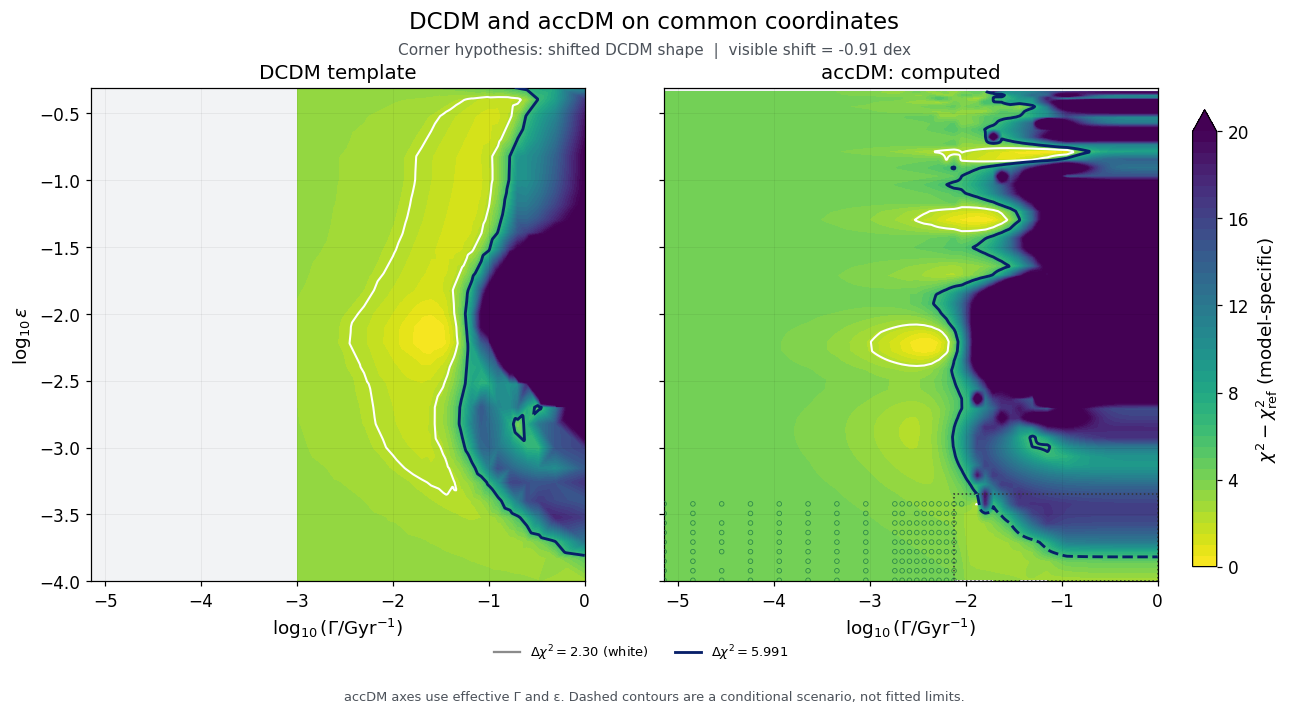

In [14]:
def mass_from_logepsilon(logeps):
    eps = 10.0**np.asarray(logeps, dtype=float)
    recoil = eps/np.sqrt(1-2*eps)
    # Stable form of sqrt(1+r^2)-1.
    eta = recoil**2/(np.sqrt(1+recoil**2)+1)
    return 11-np.log10(eta)


def fraction_from_loggamma(loggamma):
    frac = -np.expm1(-T_REFERENCE_GYR*10.0**np.asarray(loggamma, dtype=float))
    return np.log10(frac)


gx = np.linspace(*PLOT_XLIM, PLOT_RESOLUTION[0])
ey = np.linspace(*PLOT_YLIM, PLOT_RESOLUTION[1])
gg, ee = np.meshgrid(gx, ey)
common_m = mass_from_logepsilon(ee)
common_f = fraction_from_loggamma(gg)


def common_surface(values):
    interp = RegularGridInterpolator((y_grid, x_grid), values,
                                     bounds_error=False, fill_value=np.nan)
    return interp_native(interp, common_m, common_f)


dcdm_common, _ = dcdm_shape(gg, ee)
accdm_common = common_surface(completed_delta_grid)
shape_only_common = common_surface(shape_only_delta_grid)
# A contour is labelled forecast if any corner node in its bilinear cell is forecast.
forecast_influence = common_surface(forecast_grid.astype(float)) > 1e-10
corner_common = (ee < EDGE_LOGEPS) & (gg > EDGE_LOGGAMMA)
edge_hold_influence = common_surface((provenance_grid == "template_edge_hold").astype(float)) > 1e-10


def draw_levels(ax, field, forecast=None):
    forecast = np.zeros(field.shape, bool) if forecast is None else forecast
    for assumed, style in [(False, "solid"), (True, "dashed")]:
        for level, color, width in zip(CONTOUR_LEVELS, ["white", "#071f69"], [1.35, 1.85]):
            z = np.ma.masked_where((forecast != assumed) | ~np.isfinite(field), field)
            if z.count() and z.min() < level < z.max():
                ax.contour(gx, ey, z, levels=[level], colors=[color],
                           linewidths=[width], linestyles=[style], zorder=4)


def plot_map(ax, field, title, forecast=None, points=False, corner_box=False):
    ax.set_facecolor("#f2f3f5")
    filled = ax.contourf(gx, ey, np.minimum(np.maximum(field, 0), DISPLAY_DELTA_MAX+0.01),
                         levels=np.linspace(0, DISPLAY_DELTA_MAX, 41),
                         cmap="viridis_r", extend="max")
    draw_levels(ax, field, forecast)
    if SHOW_FORECAST_HATCH and forecast is not None and forecast.any():
        ax.contourf(gx, ey, np.where(forecast, 1., np.nan), levels=[0.5, 1.5],
                    colors="none", hatches=[".."])
    if corner_box:
        ax.add_patch(Rectangle((EDGE_LOGGAMMA, PLOT_YLIM[0]),
            PLOT_XLIM[1]-EDGE_LOGGAMMA, EDGE_LOGEPS-PLOT_YLIM[0],
            fill=False, edgecolor="#333333", linewidth=1.0, linestyle=":"))
    if points and SHOW_EXTENSION_POINTS and len(extension_completed):
        p = extension_completed
        x = np.log10(gamma_effective_from_log10_fraction(p.log10f_acc))
        y = np.log10(epsilon_effective_from_log10_mass(p.log10m_acc))
        finite = np.isfinite(x) & np.isfinite(y)
        ax.scatter(x[finite], y[finite], s=9, facecolors="none",
                   edgecolors="#197346", linewidths=0.55, alpha=0.75, zorder=6)
    ax.set(xlim=PLOT_XLIM, ylim=PLOT_YLIM, title=title,
           xlabel=r"$\log_{10}(\Gamma / {\rm Gyr}^{-1})$")
    ax.grid(color="black", alpha=0.05, linewidth=0.7)
    return filled


legend_handles = [
    Line2D([], [], color="#8b8b8b", lw=1.5, label=r"$\Delta\chi^2=2.30$ (white)"),
    Line2D([], [], color="#071f69", lw=1.85, label=r"$\Delta\chi^2=5.991$"),
    # Line2D([], [], color="#071f69", lw=1.85, ls="--", label="assumed continuation"),
    # Line2D([], [], marker="o", color="none", markerfacecolor="none",
    #        markeredgecolor="#197346", markersize=5, label="completed extension fit"),
]


def save_figure(fig, stem):
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        for ext in ("png", "pdf"):
            fig.savefig(OUTPUT_DIR / f"{stem}.{ext}", bbox_inches="tight")


fig_full, axs = plt.subplots(1, 2, figsize=(12.2, 6.7), sharex=True, sharey=True)
fig_full.subplots_adjust(left=.08, right=.875, bottom=.19, top=.86, wspace=.16)
plot_map(axs[0], dcdm_common, "DCDM template")
filled = plot_map(axs[1], accdm_common, "accDM: computed",
                  forecast_influence, points=True, corner_box=True)
axs[0].set_ylabel(r"$\log_{10}\epsilon$")
color_ax = fig_full.add_axes([.901, .21, .018, .62])
fig_full.colorbar(filled, cax=color_ax, ticks=np.arange(0, 21, 4),
                  label=r"$\chi^2-\chi^2_{\rm ref}$ (model-specific)")
fig_full.suptitle("DCDM and accDM on common coordinates", y=.965, fontsize=15)
fig_full.text(.5, .905,
    f"Corner hypothesis: shifted DCDM shape  |  visible shift = {-SHIFT:+.2f} dex",
    ha="center", fontsize=10, color="#4c525a")
fig_full.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(.49, .064),
                ncol=4, fontsize=8.5, frameon=False)
fig_full.text(.5, .029,
    "accDM axes use effective Γ and ε. Dashed contours are a conditional scenario, not fitted limits.",
    ha="center", fontsize=8.5, color="#4c525a")
save_figure(fig_full, "dcdm_accdm_full_comparison")
plt.show()

## 7. Zbliżenie: sam kształt vs mapa z zachowanymi punktami

Środkowy panel pokazuje hipotetyczne pole DCDM również tam, gdzie w rogu pojawiły
się już wyniki. Prawy panel przywraca wszystkie ukończone fity. Dzięki temu można
sprawdzić, czy nowe wyniki faktycznie wspierają założoną morfologię. Żaden z tych
rysunków nie jest niezależną walidacją: kształt jest przyjętym scenariuszem.

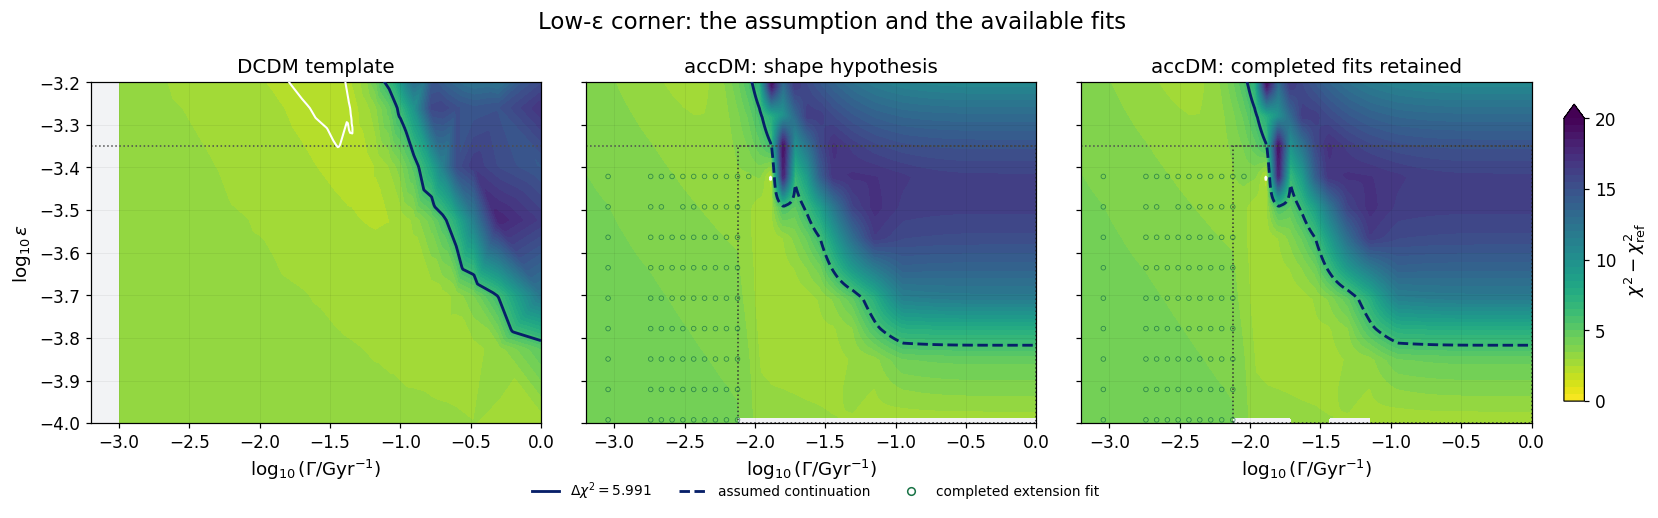

Sprawdzenie scenariusza w ukończonych punktach rogu (niezależne od kalibracji przesunięcia):


,log10m_acc,log10f_acc,measured_chi2,scenario_chi2,scenario_minus_measured
0,18.142857,-0.925,192.669265,192.38333,-0.285935


MAE = 0.28593468515722975


In [9]:
fig_zoom, axs = plt.subplots(1, 3, figsize=(15.5, 5.0), sharex=True, sharey=True)
fig_zoom.subplots_adjust(left=.065, right=.91, bottom=.21, top=.83, wspace=.10)
plot_map(axs[0], dcdm_common, "DCDM template")
plot_map(axs[1], shape_only_common, "accDM: shape hypothesis",
         corner_common, points=True, corner_box=True)
filled = plot_map(axs[2], accdm_common, "accDM: completed fits retained",
                  forecast_influence, points=True, corner_box=True)
zoom_bottom = max(PLOT_YLIM[0], float(np.nanmin(native_e)))
for ax in axs:
    ax.set_xlim(max(PLOT_XLIM[0], min(-3.2, EDGE_LOGGAMMA-.4)), PLOT_XLIM[1])
    ax.set_ylim(zoom_bottom, EDGE_LOGEPS+.15)
    ax.axhline(EDGE_LOGEPS, ls=":", color="0.3", lw=1)
axs[0].set_ylabel(r"$\log_{10}\epsilon$")
cax = fig_zoom.add_axes([.929, .25, .012, .54])
fig_zoom.colorbar(filled, cax=cax, ticks=np.arange(0, 21, 5), label=r"$\chi^2-\chi^2_{\rm ref}$")
fig_zoom.suptitle("Low-ε corner: the assumption and the available fits", y=.96, fontsize=15)
fig_zoom.legend(handles=legend_handles[1:], loc="lower center", ncol=3,
                bbox_to_anchor=(.49, .045), frameon=False, fontsize=9)
save_figure(fig_zoom, "dcdm_accdm_corner_zoom")
plt.show()

# Numerical tension between the pure scenario and actual completed corner fits.
checks = corner_mask & measured_mask & np.isfinite(conditional_delta_grid)
corner_check = pd.DataFrame({
    "log10m_acc": native_m[checks], "log10f_acc": native_f[checks],
    "measured_chi2": chi_raw_grid[checks],
    "scenario_chi2": conditional_delta_grid[checks]+REFERENCE_CHI2,
})
corner_check["scenario_minus_measured"] = corner_check.scenario_chi2-corner_check.measured_chi2
if len(corner_check):
    print("Sprawdzenie scenariusza w ukończonych punktach rogu (niezależne od kalibracji przesunięcia):")
    display(corner_check)
    print("MAE =", float(corner_check.scenario_minus_measured.abs().mean()))
else:
    print("Brak ukończonych punktów rogu do tego sprawdzenia.")

## 8. Wrażliwość na założenie przesunięcia

Zmiana o ±0.20 dex to **trzy wybrane scenariusze**, nie oszacowanie błędu ani
68%/95% przedział. Poza brakującym rogiem wszystkie trzy mapy są identyczne.
W ustawieniach można niezależnie zmienić amplitudę, poziom i szerokości zszycia.

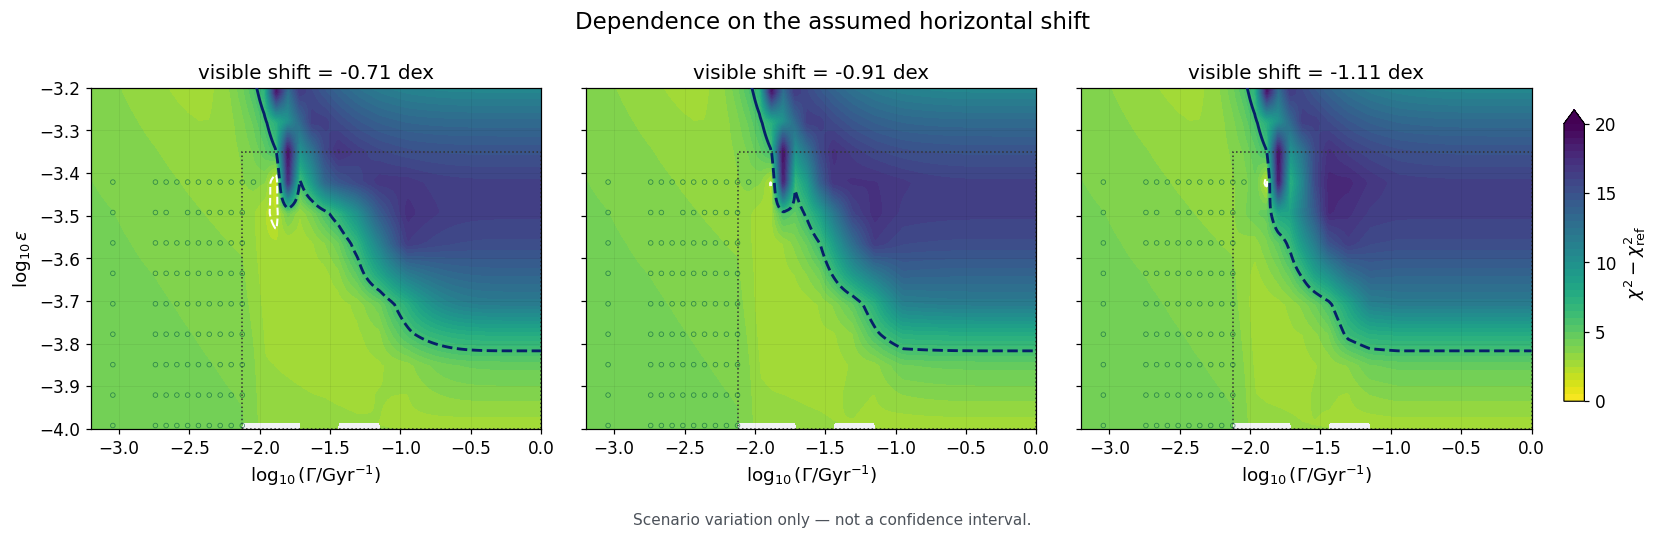

,query_shift,displayed_shift,forecast_cells,edge_held_cells,unsupported_cells
0,0.712082,-0.712082,107,9,5
1,0.912082,-0.912082,107,9,5
2,1.112082,-1.112082,107,18,5


In [ ]:
shift_variants = [SHIFT-SHIFT_SENSITIVITY_DEX, SHIFT, SHIFT+SHIFT_SENSITIVITY_DEX]
fig_sensitivity, axs = plt.subplots(1, 3, figsize=(15.5, 5.0), sharex=True, sharey=True)
fig_sensitivity.subplots_adjust(left=.065, right=.91, bottom=.20, top=.82, wspace=.10)
sensitivity_rows = []
for ax, shift in zip(axs, shift_variants):
    surface, _, _, supported, provenance, forecast = complete_map(shift)
    field = common_surface(surface)
    influenced = common_surface(forecast.astype(float)) > 1e-10
    filled = plot_map(ax, field, f"visible shift = {-shift:+.2f} dex",
                      influenced, points=True, corner_box=True)
    ax.set_xlim(max(PLOT_XLIM[0], min(-3.2, EDGE_LOGGAMMA-.4)), PLOT_XLIM[1])
    ax.set_ylim(zoom_bottom, EDGE_LOGEPS+.15)
    sensitivity_rows.append(dict(query_shift=shift, displayed_shift=-shift,
        forecast_cells=int(forecast.sum()),
        edge_held_cells=int(np.sum(provenance == "template_edge_hold")),
        unsupported_cells=int(np.sum(provenance == "unsupported"))))
axs[0].set_ylabel(r"$\log_{10}\epsilon$")
cax = fig_sensitivity.add_axes([.929, .25, .012, .53])
fig_sensitivity.colorbar(filled, cax=cax, ticks=np.arange(0, 21, 5), label=r"$\chi^2-\chi^2_{\rm ref}$")
# fig_sensitivity.suptitle("Dependence on the assumed horizontal shift", y=.96, fontsize=15)
fig_sensitivity.text(.5, .025, "Scenario variation only — not a confidence interval.",
                    ha="center", fontsize=10, color="#4c525a")
save_figure(fig_sensitivity, "dcdm_accdm_shift_sensitivity")
plt.show()
display(pd.DataFrame(sensitivity_rows))

## 9. Eksport i sprawdzenia techniczne

`accdm_completed_corner.csv` zapisuje **surowe χ²**, wartość prezentacyjną,
oddzielny scenariusz oraz pochodzenie każdej komórki. Wartości uzupełnione nie są
przepisywane do wejściowych katalogów fitów. `corner_assumption_check.csv` służy
do porównania z ukończonymi punktami. Tabela kalibracji i SHA-256 wejść pozwalają
ustalić, z jakich danych powstał rysunek.

Przy ponownym Run All nowe ukończone fity zastępują uzupełnienie. To aktualny
scenariusz diagnostyczny, nie zamrożona prognoza do prospektywnej walidacji.
Do porównania z przyszłymi wynikami zachowaj kopię CSV i metadanych z wybranej daty.

In [11]:
# Round-trip of the adopted coordinate map.
mass_roundtrip = mass_from_logepsilon(np.log10(epsilon_effective_from_log10_mass(x_grid)))
finite_f = y_grid[y_grid < 0]
fraction_roundtrip = fraction_from_loggamma(np.log10(gamma_effective_from_log10_fraction(finite_f)))
assert np.max(np.abs(mass_roundtrip-x_grid)) < 1e-8
assert np.max(np.abs(fraction_roundtrip-finite_f)) < 1e-8

audit = pd.DataFrame({
    "log10m_acc": native_m.ravel(), "log10f_acc": native_f.ravel(),
    "log10_epsilon_eff": native_e.ravel(), "log10_gamma_eff": native_g.ravel(),
    "raw_chi2": chi_raw_grid.ravel(),
    "display_chi2": (completed_delta_grid+REFERENCE_CHI2).ravel(),
    "delta_chi2": completed_delta_grid.ravel(),
    "shape_only_chi2": (shape_only_delta_grid+REFERENCE_CHI2).ravel(),
    "provenance": provenance_grid.ravel(),
    "inside_native_dcdm_support_after_shift": template_supported_grid.ravel(),
    "is_missing_corner_forecast": forecast_grid.ravel(),
})
audit["coordinate_key"] = [coordinate_key(m, f) for m, f in zip(audit.log10m_acc, audit.log10f_acc)]
audit["planned_grid_point"] = audit.coordinate_key.isin(set(expected_points.coordinate_key))

metadata = {
    "purpose": "conditional DCDM-shape scenario; not a fitted likelihood in missing cells",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "reference_chi2_accdm": REFERENCE_CHI2,
    "reference_chi2_dcdm": float(dcdm.chi2.min()),
    "base_csv": str(base_sampled_path), "base_csv_sha256": sha256_file(base_sampled_path),
    "dcdm_csv": str(DCDM_PROFILE_CSV), "dcdm_csv_sha256": DCDM_FILE_HASH,
    "campaigns": [{"label": s["label"], "directory": str(s["directory"]),
                    "manifest_sha256": sha256_file(Path(s["directory"])/"manifest.csv")}
                   for s in EXTENSION_CAMPAIGNS],
    "completed_input_sha256": hashlib.sha256(sampled.sort_values("coordinate_key")[[
        "coordinate_key", "chi2_one_loop", "source_label"]].to_csv(index=False).encode()).hexdigest(),
    "measured_points": int(measured_mask.sum()), "missing_corner_points": int(missing_corner_mask.sum()),
    "provenance_counts": {str(k): int(v) for k, v in pd.Series(provenance_grid.ravel()).value_counts().items()},
    "displayed_loggamma_shift": -SHIFT, "query_shift": SHIFT, "shift_method": SHIFT_METHOD,
    "template_amplitude": TEMPLATE_AMPLITUDE, "template_offset": TEMPLATE_OFFSET,
    "eps_blend_dex": EPS_BLEND_DEX, "gamma_blend_dex": GAMMA_BLEND_DEX,
    "gamma_outside_policy": TEMPLATE_GAMMA_OUTSIDE,
    "edge_logepsilon": EDGE_LOGEPS, "edge_loggamma": EDGE_LOGGAMMA,
    "sensitivity_is_confidence_interval": False,
    "known_repaired_coordinates": list(KNOWN_LOWF_REPAIR_COORDS),
    "negative_forecast_delta_values": int(np.sum(forecast_grid & (completed_delta_grid < 0))),
    "normalization": "fixed measured references; no re-minimization over forecast cells",
}

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    audit.to_csv(OUTPUT_DIR / "accdm_completed_corner.csv", index=False)
    corner_check.to_csv(OUTPUT_DIR / "corner_assumption_check.csv", index=False)
    shift_calibration.to_csv(OUTPUT_DIR / "shift_calibration.csv", index=False)
    repair_audit.to_csv(OUTPUT_DIR / "known_outlier_repairs.csv", index=False)
    pd.DataFrame(sensitivity_rows).to_csv(OUTPUT_DIR / "shift_sensitivity.csv", index=False)
    np.savez_compressed(OUTPUT_DIR / "comparison_surfaces.npz",
        log10gamma=gx, log10epsilon=ey, dcdm_delta=dcdm_common,
        accdm_delta=accdm_common, shape_only_delta=shape_only_common,
        forecast_influence=forecast_influence, edge_hold_influence=edge_hold_influence)
    (OUTPUT_DIR / "comparison_metadata.json").write_text(
        json.dumps(metadata, indent=2, ensure_ascii=False, allow_nan=False)+"\n", encoding="utf-8")
    print("Zapisano rysunki i tabele w:", OUTPUT_DIR)
print("OK: wszystkie ukończone punkty poza jawnymi naprawami zachowane; transformacje osi odwracalne.")

Zapisano rysunki i tabele w: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_dcdm_accdm_corner_comparison_v1
OK: wszystkie ukończone punkty poza jawnymi naprawami zachowane; transformacje osi odwracalne.
